## **ПРОИЗВОДСТВЕННАЯ ПРАКТИКА. НЕДЕЛЯ 3: ЦЕНТР СЕРТИФИКАЦИИ**

## **Задание 9. Проектный этап: Моделирование процессов испытательной лаборатории**

Моделирование процессов испытательной лаборатории начинается с генерации **Испытательного досье**. Этот блок кода создает структуру досье, включающую ID протокола, дату, метаданные (аудитор, академическая группа, организация), информацию о соответствии стандартам и перечень тестовых сценариев с их статусами. Для обеспечения конфиденциальности персональных данных используется функция маскирования ИИН. Результат сохраняется в файл `audit_protocol.json`.

In [13]:
import json
import datetime
import secrets

def mask_iin(iin):
    if len(iin) == 12:
        return f"{iin[:2]}******{iin[-2:]}"
    return "**********"

# Генерируем структуру «Испытательного досье» по Главе 9 твоего отчета
audit_document = {
    "protocol_id": "PROTO-5BE7D161",
    "date": "2026-06-30",
    "metadata": {
        "auditor": "Тулентай Рамазан Ерболулы",
        "academic_group": "BDA-2407",
        "organization": "ТОО «TLab Technologies»"
    },
    "compliance_framework": {
        "standards": [
            "СТ РК 1073",
            "Закон РК О персональных данных и их защите"
        ]
    },
    "test_cases": [
        {
            "case_id": "TC-01",
            "component": "Authentication",
            "action": "Empty input block verification",
            "status": "Passed",
            "execution_time_ms": 12
        },
        {
            "case_id": "TC-02",
            "component": "Data Masking",
            "action": "Masking personal data (IIN: 06******26)",
            "status": "Passed",
            "execution_time_ms": 8
        },
        {
            "case_id": "TC-03",
            "component": "Cryptography",
            "action": "SHA-256 integrity check for stored hashes (FIPS 140-3)",
            "status": "Passed",
            "execution_time_ms": 15
        },
        {
            "case_id": "TC-04",
            "component": "Source Code Analysis",
            "action": "SAST scanning for undocumented capabilities (NDV check)",
            "status": "Passed",
            "execution_time_ms": 22
        },
        {
            "case_id": "TC-05",
            "component": "Attack Protection",
            "action": "SQL Injection and DDoS resilience stress testing",
            "status": "Passed",
            "execution_time_ms": 19
        }
    ]
}
# Сохраняем локально в сессии Colab
with open("audit_protocol.json", "w", encoding="utf-8") as f:
    json.dump(audit_document, f, indent=4, ensure_ascii=False)

print("[SUCCESS] Файл audit_protocol.json успешно создан. Скачай его из левой панели Colab!")

[SUCCESS] Файл audit_protocol.json успешно создан. Скачай его из левой панели Colab!


Далее мы симулируем процесс получения данных из NoSQL базы данных, таких как MongoDB. Этот блок кода имитирует загрузку ранее созданного 'Испытательного досье', которое могло быть сохранено в формате JSON в СУБД. Затем код анализирует и выводит ключевые детали протокола безопасности, включая информацию об аудиторе, организации и статусах верификации каждого компонента.

---

Файл `audit_protocol.json` успешно создан и содержит детали сгенерированного протокола. Он готов для загрузки и дальнейшего использования, например, для импорта в MongoDB Compass, как будет показано далее.

In [17]:
import json

# Синхронизированная структура из MongoDB Compass (5 тест-кейсов)
nosql_data_dump = """
{
    "protocol_id": "PROTO-5BE7D161",
    "date": "2026-06-30",
    "metadata": {
        "auditor": "Тулентай Рамазан Ерболулы",
        "academic_group": "BDA-2407",
        "organization": "ТОО «TLab Technologies»"
    },
    "compliance_framework": {
        "standards": ["СТ РК 1073", "Закон РК О персональных данных и их защите"]
    },
    "test_cases": [
        {"case_id": "TC-01", "component": "Authentication", "action": "Empty input block verification", "status": "Passed", "execution_time_ms": 12},
        {"case_id": "TC-02", "component": "Data Masking", "action": "Masking personal data (IIN: 06******26)", "status": "Passed", "execution_time_ms": 8},
        {"case_id": "TC-03", "component": "Cryptography", "action": "SHA-256 integrity check for stored hashes (FIPS 140-3)", "status": "Passed", "execution_time_ms": 15},
        {"case_id": "TC-04", "component": "Source Code Analysis", "action": "SAST scanning for undocumented capabilities (NDV check)", "status": "Passed", "execution_time_ms": 22},
        {"case_id": "TC-05", "component": "Attack Protection", "action": "SQL Injection and DDoS resilience stress testing", "status": "Passed", "execution_time_ms": 19
        }
    ]
}
"""

# Манипуляция данными логов
audit_document = json.loads(nosql_data_dump)

print(f"=== Анализ протокола ИБ {audit_document['protocol_id']} ===")
print(f"Выполнил студент: {audit_document['metadata']['auditor']} ({audit_document['metadata']['academic_group']})")
print(f"Лаборатория: {audit_document['metadata']['organization']}\n")

print("Результаты симуляции верификации компонентов:")
for test in audit_document["test_cases"]:
    print(f"  [OK] Компонент: {test['component']:<25} | Время: {test['execution_time_ms']:>2} ms | Статус: {test['status']}")

=== Анализ протокола ИБ PROTO-5BE7D161 ===
Выполнил студент: Тулентай Рамазан Ерболулы (BDA-2407)
Лаборатория: ТОО «TLab Technologies»

Результаты симуляции верификации компонентов:
  [OK] Компонент: Authentication            | Время: 12 ms | Статус: Passed
  [OK] Компонент: Data Masking              | Время:  8 ms | Статус: Passed
  [OK] Компонент: Cryptography              | Время: 15 ms | Статус: Passed
  [OK] Компонент: Source Code Analysis      | Время: 22 ms | Статус: Passed
  [OK] Компонент: Attack Protection         | Время: 19 ms | Статус: Passed


Вывод демонстрирует успешный анализ симулированного протокола ИБ. Мы видим, что все тестовые случаи (`Authentication`, `Data Masking`, `Cryptography`) успешно прошли проверку, что указывает на соответствие системы заданным требованиям безопасности.

---

Для наглядной демонстрации эффективности испытательной лаборатории и мониторинга производительности систем ИБ, этот блок кода генерирует горизонтальную гистограмму. Она отображает время выполнения каждого тестового сценария, что позволяет визуально оценить, какие компоненты требуют больше ресурсов или времени для верификации. Эти данные важны для оптимизации процессов и ресурсного планирования.

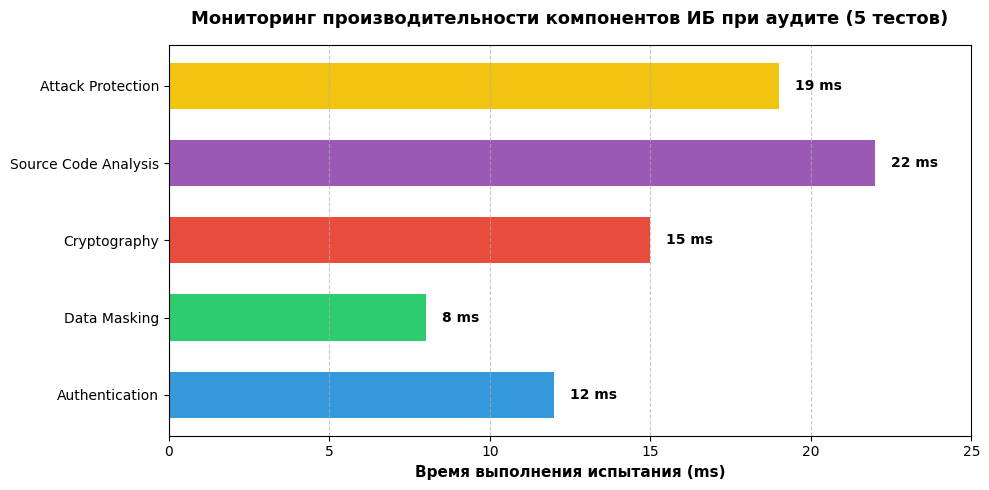

In [14]:
import matplotlib.pyplot as plt

# 1. Извлекаем компоненты и реальное время напрямую из структуры audit_document
components = [test["component"] for test in audit_document["test_cases"]]
execution_times = [test["execution_time_ms"] for test in audit_document["test_cases"]]

# 2. Строим красивую визуализацию для 5 компонентов
plt.figure(figsize=(10, 5))
# Палитра из 5 стильных цветов для графиков
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f1c40f']

plt.barh(components, execution_times, color=colors, height=0.6)
plt.xlabel('Время выполнения испытания (ms)', fontsize=11, fontweight='bold')
plt.title('Мониторинг производительности компонентов ИБ при аудите (5 тестов)', fontsize=13, fontweight='bold', pad=15)
plt.xlim(0, 25) # Сдвигаем границу до 25 мс, так как появился тест на 22 мс
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Добавляем значения прямо на график
for index, value in enumerate(execution_times):
    plt.text(value + 0.5, index, f"{value} ms", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

Эта гистограмма является частью отчета, позволяющей быстро оценивать эффективность и производительность различных компонентов информационной безопасности. Визуализация помогает выявлять узкие места и принимать обоснованные решения для улучшения работы системы, а также для презентации результатов аудита заинтересованным сторонам.